Benjamin Arnold; 08/26/2026; Lab 1 -- Projectile Motion Solver.

Part A-- One-Dimensional Free-Fall

Final time is 4.529999999999948 s, and the final velocity is -44.43930000000012 m/s. The exact values are 4.515 s and -44.294 m/s, respectively.


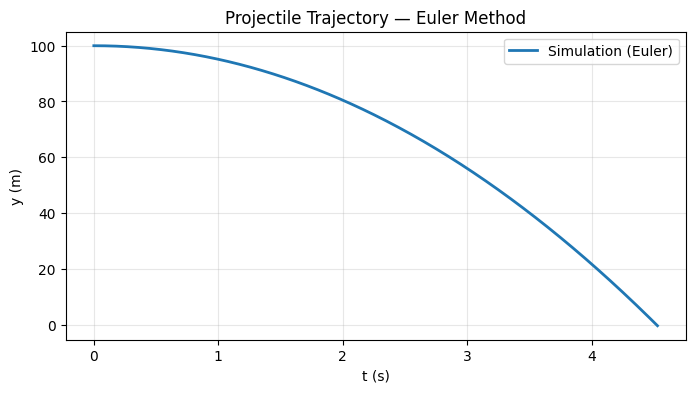

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_freefall(h,dt,g=9.81):
    y, vy=h,0
    t=0.0

    t_arr, y_arr, vy_arr=[t],[y],[vy]

    while y>=0:
        ay=-g
        y=y+vy*dt
        vy=vy+ay*dt
        t=t+dt

        t_arr.append(t)
        y_arr.append(y)
        vy_arr.append(vy)
    return t_arr,y_arr,vy_arr

t,y,vy=simulate_freefall(100,0.01,g=9.81)
print(f'Final time is {t[-1]} s, and the final velocity is {vy[-1]} m/s. The exact values are 4.515 s and -44.294 m/s, respectively.')

plt.figure(figsize=(8, 4))
plt.plot(t, y, linewidth=2, label='Simulation (Euler)')
plt.xlabel('t (s)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory — Euler Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Notes: The exact values are roughly t=4.515 s and vy=-44.294 m/s. The numerical results for dt=0.1 are 
t=4.6 s and -45.126 m/s. The percentage error for each is 1.88%. For dt=1, the error is 32.88%, and for dt=0.001 the error is 0.327%.

Part B-- Two-Dimensional Projectile

The error in the range is 15.611958724000525%, in the max height is 24.294917448001005%, and in the flight time is 15.611958724000527%.


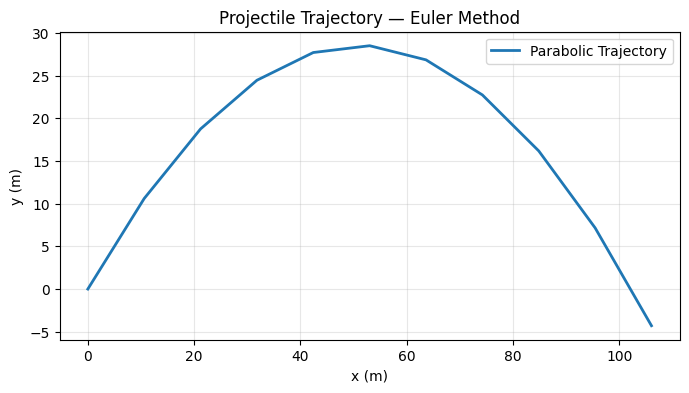

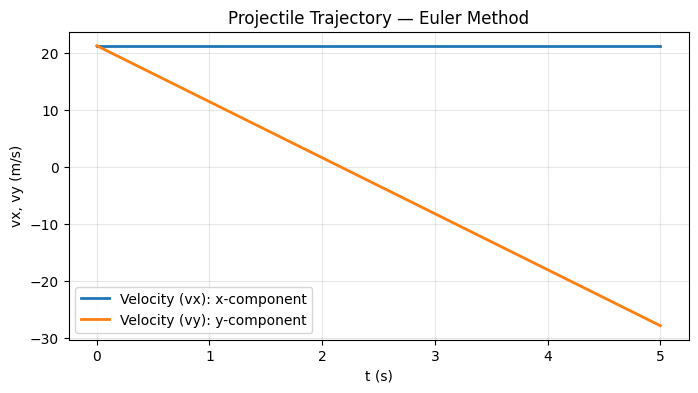

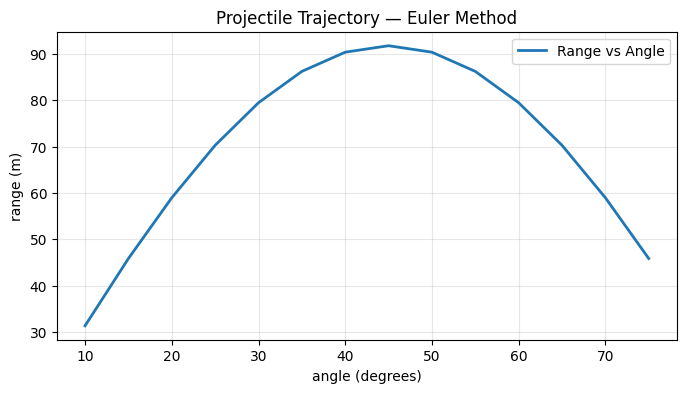

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_projectile_2d(v0,theta_deg,dt,g=9.81):
    ay,ax=-g,0
    x,y=0,0
    vx=v0*np.cos(theta_deg*np.pi/180)
    vy=v0*np.sin(theta_deg*np.pi/180)
    t=0.0

    t_arr,x_arr,y_arr,vy_arr,vx_arr=[t],[x],[y],[vy],[vx]

    while (y>=0):
        x=x+vx*dt
        y=y+vy*dt
        vx=vx+ax*dt
        vy=vy+ay*dt
        t=t+dt

        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vy_arr.append(vy)
        vx_arr.append(vx)
    return t_arr,x_arr,y_arr,vx_arr,vy_arr


v0=30
theta_deg=45
t,x,y,vx,vy=simulate_projectile_2d(v0,theta_deg,0.5,g=9.81)

rng=((v0)**2)*(np.sin(2*(theta_deg*np.pi/180)))/9.81
max_height=((v0**2)*((np.sin(theta_deg*np.pi/180))**2))/(2*9.81)
flight_time=(2*v0*(np.sin(theta_deg*np.pi/180)))/9.81

rng_err=((np.max(x)-rng)/rng)*100
max_height_err=((np.max(y)-max_height)/max_height)*100
flight_time_err=((t[-1]-flight_time)/flight_time)*100

print(f'The error in the range is {rng_err}%, in the max height is {max_height_err}%, and in the flight time is {flight_time_err}%.')


plt.figure(figsize=(8, 4))
plt.plot(x, y, linewidth=2, label='Parabolic Trajectory')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory — Euler Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, vx, linewidth=2, label='Velocity (vx): x-component')
plt.plot(t, vy, linewidth=2, label='Velocity (vy): y-component')
plt.xlabel('t (s)')
plt.ylabel('vx, vy (m/s)')
plt.title('Projectile Trajectory — Euler Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


theta=np.arange(10,80,5)
def range(theta_deg=theta,v0=v0):
    rng=((v0)**2)*(np.sin(2*(theta_deg*np.pi/180)))/9.81
    return rng
r=range()

plt.figure(figsize=(8, 4))
plt.plot(theta,r, linewidth=2, label='Range vs Angle')
plt.xlabel('angle (degrees)')
plt.ylabel('range (m)')
plt.title('Projectile Trajectory — Euler Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Notes: 
(a.) The components of velocity are linear and constant respectively because a force is acting on the y-component (gravity), whereas no force is acting on the x-component; that is to say, in the second-order differential equations of Newton, the first derivative will pick up linear time-dependence in the y direction but only a constant in the x direction. Hence, the shape of vx is a horizontal line, and the shape of vy is a line that is neither vertical or horizontal.

(b.) The angle for the maximum range is given numerically at 45 degrees, which exactly matches theory. The formula for the range, derived from Kinematics, gives us a proportion of sin(2x), and this is maximized when sin(2x)=1, which happens at x=pi/4. This equation is used in the simulation, so it ought to match for sufficiently small dt.

(c.) As we increase dt, the error in the various outputs (like range, flight time, max height) increses quite significantly. For example, in the angle vs range graph above, the curve has shifted to the right, making it seem as though max range is achieved at an angle greater than 45 degrees.

Part C-- Projectile with Air Resistance

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

